/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: /Users/milliespencer/Downloads/Re_ Following up on our conversation at Western Snow - Rock glacier project incorporating ASO flights (1)/ASO_CO_20260519_targets/ASO_CO_20260519_targets.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


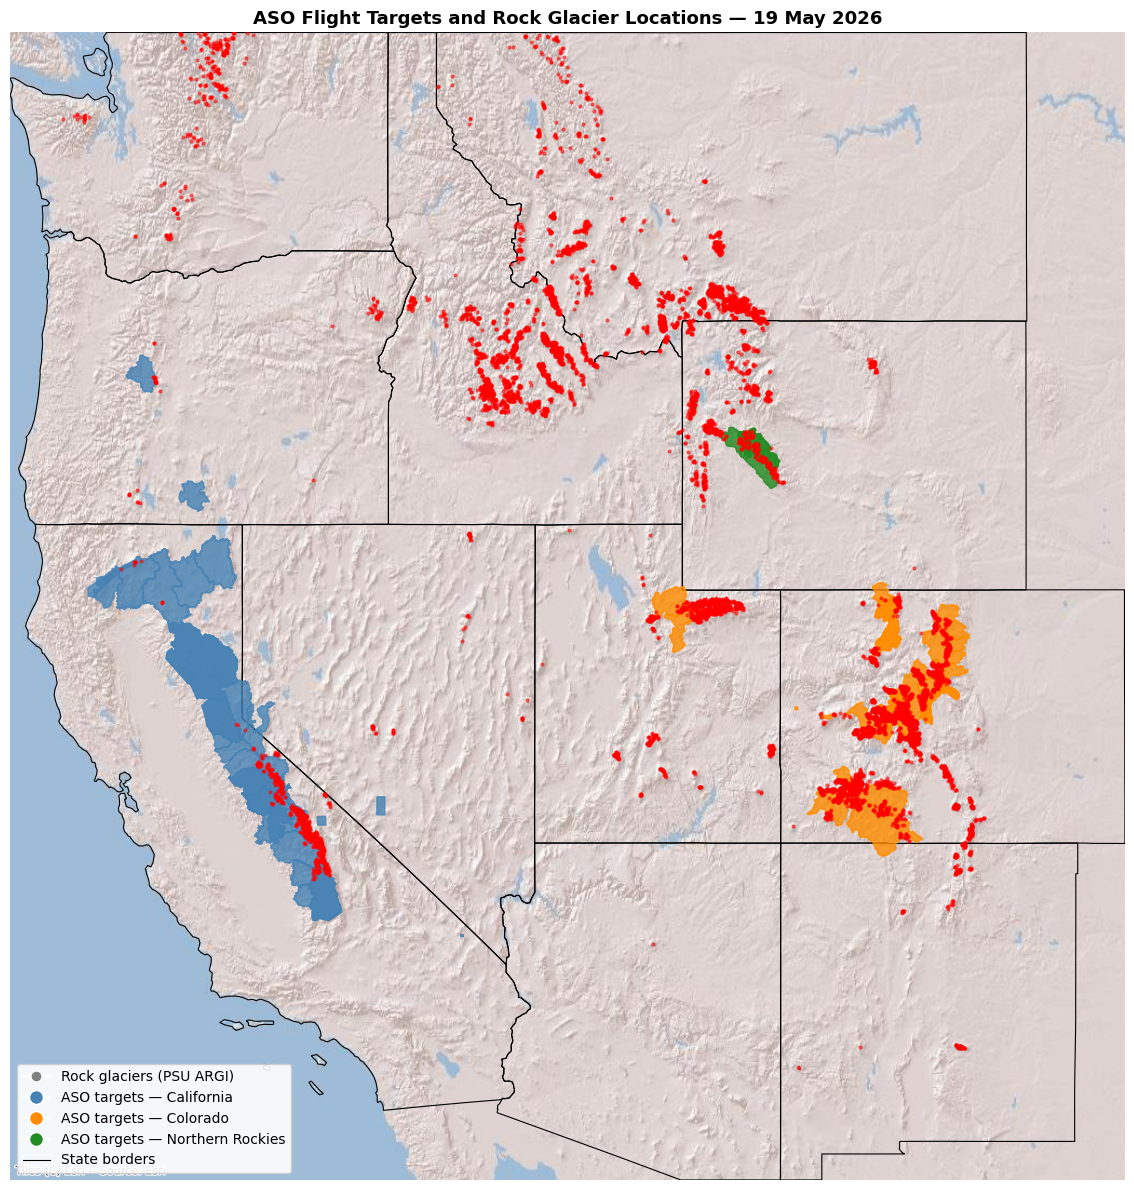

In [1]:
import geopandas as gpd
import matplotlib.pyplot as plt
import contextily as ctx
from matplotlib.lines import Line2D
import requests
from io import BytesIO
import zipfile

# Load ASO and rock glacier shapefiles
base = '/Users/milliespencer/Downloads/Re_ Following up on our conversation at Western Snow - Rock glacier project incorporating ASO flights (1)'

gdf_ca = gpd.read_file(f'{base}/ASO_CA_20260519_targets/ASO_CA_20260519_targets.shp').to_crs('EPSG:3857')
gdf_co = gpd.read_file(f'{base}/ASO_CO_20260519_targets/ASO_CO_20260519_targets.shp').to_crs('EPSG:3857')
gdf_nr = gpd.read_file(f'{base}/ASO_NR_20260519_targets/ASO_NR_20260519_targets.shp').to_crs('EPSG:3857')
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp').to_crs('EPSG:3857')

# Load US state borders from Census Bureau
states_url = 'https://www2.census.gov/geo/tiger/GENZ2022/shp/cb_2022_us_state_20m.zip'
r = requests.get(states_url)
with zipfile.ZipFile(BytesIO(r.content)) as z:
    z.extractall('/tmp/us_states')
gdf_states = gpd.read_file('/tmp/us_states/cb_2022_us_state_20m.shp').to_crs('EPSG:3857')

# Clip to western US
western = ['CA', 'OR', 'WA', 'ID', 'MT', 'WY', 'CO', 'UT', 'NV', 'AZ', 'NM']
gdf_west = gdf_states[gdf_states['STUSPS'].isin(western)]

fig, ax = plt.subplots(figsize=(12, 12))

# State borders
gdf_west.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.8, zorder=2)

gdf_ca.plot(ax=ax, color='steelblue',   edgecolor='steelblue',   alpha=0.8, zorder=4)
gdf_co.plot(ax=ax, color='darkorange',  edgecolor='darkorange',  alpha=0.8, zorder=4)
gdf_nr.plot(ax=ax, color='forestgreen', edgecolor='forestgreen', alpha=0.8, zorder=4)

# Rock glaciers on top
gdf_rg.copy().assign(geometry=gdf_rg.centroid).plot(
    ax=ax, color='red', markersize=4, alpha=0.5, zorder=5)

ctx.add_basemap(ax, source=ctx.providers.Esri.WorldShadedRelief, zoom=6)

# Zoom to western US extent
minx, miny, maxx, maxy = gdf_west.total_bounds
ax.set_xlim(minx, maxx)
ax.set_ylim(miny, maxy)

legend_elements = [
    Line2D([0],[0], marker='o', color='w', markerfacecolor='grey',
           markersize=8,  label='Rock glaciers (PSU ARGI)'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='steelblue',
           markersize=10, label='ASO targets — California'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='darkorange',
           markersize=10, label='ASO targets — Colorado'),
    Line2D([0],[0], marker='o', color='w', markerfacecolor='forestgreen',
           markersize=10, label='ASO targets — Northern Rockies'),
    Line2D([0],[0], color='black', linewidth=0.8,
           label='State borders'),
]
ax.legend(handles=legend_elements, fontsize=10, loc='lower left', framealpha=0.9)
ax.set_title('ASO Flight Targets and Rock Glacier Locations — 19 May 2026',
             fontsize=13, fontweight='bold')
ax.set_axis_off()
plt.tight_layout()
plt.savefig('ASO_rockglacier_targets_map.png', dpi=200, bbox_inches='tight')
plt.show()


### spatially join where ASO flights intersected w rock glaciers

In [2]:
import geopandas as gpd
import pandas as pd
import numpy as np

# ── 1. Load and reproject ──────────────────────────────────────────────────
base = '/Users/milliespencer/Downloads/Re_ Following up on our conversation at Western Snow - Rock glacier project incorporating ASO flights (1)'

gdf_ca = gpd.read_file(f'{base}/ASO_CA_20260519_targets/ASO_CA_20260519_targets.shp')
gdf_co = gpd.read_file(f'{base}/ASO_CO_20260519_targets/ASO_CO_20260519_targets.shp')
gdf_nr = gpd.read_file(f'{base}/ASO_NR_20260519_targets/ASO_NR_20260519_targets.shp')
gdf_rg = gpd.read_file('/Users/milliespencer/Downloads/PSU_ARGI/PSU_ARGI.shp')

# Tag each ASO region before merging
gdf_ca['aso_region'] = 'California'
gdf_co['aso_region'] = 'Colorado'
gdf_nr['aso_region'] = 'Northern Rockies'
gdf_aso = pd.concat([gdf_ca, gdf_co, gdf_nr], ignore_index=True)

# Work in EPSG:4326 for ITS_LIVE queries; use a planar CRS for the join
CRS_QUERY = 'EPSG:4326'
CRS_JOIN  = 'EPSG:5070'   # Albers Equal Area CONUS — good for spatial joins

gdf_aso_join = gdf_aso.to_crs(CRS_JOIN)
gdf_rg_join  = gdf_rg.to_crs(CRS_JOIN)

# ── 2. Spatial join: rock glaciers within ASO footprints ───────────────────
# Use centroid of each rock glacier polygon for the join
gdf_rg_pts = gdf_rg_join.copy()
gdf_rg_pts['geometry'] = gdf_rg_join.centroid


joined = gpd.sjoin(gdf_rg_pts, gdf_aso_join[['geometry', 'aso_region']],
                   how='inner', predicate='within')

# Get centroid coords in 4326 for ITS_LIVE
joined_4326 = joined.copy()
joined_4326['lon'] = joined_4326['LONG']
joined_4326['lat'] = joined_4326['LAT']

print(f"{len(joined_4326)} rock glaciers within ASO footprints")
print(joined_4326['aso_region'].value_counts())

/Users/milliespencer/miniconda3/envs/glacier-env/lib/python3.10/site-packages/pyogrio/raw.py:198: RuntimeWarning: /Users/milliespencer/Downloads/Re_ Following up on our conversation at Western Snow - Rock glacier project incorporating ASO flights (1)/ASO_CO_20260519_targets/ASO_CO_20260519_targets.shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


4893 rock glaciers within ASO footprints
aso_region
Colorado            3836
California           706
Northern Rockies     351
Name: count, dtype: int64


### Play with ITS_LIVE  - NASA glacier velocity tool 

In [3]:
import s3fs as s3
import xarray as xr
import importlib
import sys

# Force reload of patched datacube_tools
if 'datacube_tools' in sys.modules:
    del sys.modules['datacube_tools']

# Patch datacube_tools to work with modern s3fs
import datacube_tools as dct_module

original_init = dct_module.DATACUBETOOLS.__init__

def patched_init(self, use_catalog="all"):
    from pyproj import Transformer
    import json
    
    self.catalog = {"all": "s3://its-live-data/datacubes/catalog_v02.json"}
    self.transformer_3031 = Transformer.from_crs(4326, 3031, always_xy=True)
    
    # Modern s3fs anonymous access
    self._s3fs = s3.S3FileSystem(anon=True)
    self.open_cubes = {}
    self._current_catalog = use_catalog
    
    with self._s3fs.open(self.catalog[use_catalog], "r") as incubejson:
        self._json_all = json.load(incubejson)
    self.json_catalog = self._json_all
    
    # Skip the Antarctica elevation dataset — not needed for WUS rock glaciers
    self.elevation_dataset = None

dct_module.DATACUBETOOLS.__init__ = patched_init

In [27]:
import importlib, sys
for mod in list(sys.modules.keys()):
    if 'datacube' in mod or 'itslive' in mod:
        del sys.modules[mod]

sys.path.insert(0, '/Users/milliespencer/WUS_rock_glaciers')

import s3fs
import json
from datacube_tools import DATACUBETOOLS as dctools
import datacube_tools as dct_module

def patched_init(self, use_catalog="all"):
    from pyproj import Transformer
    self.catalog = {"all": "s3://its-live-data/datacubes/catalog_v02.json"}
    self.transformer_3031 = Transformer.from_crs(4326, 3031, always_xy=True)
    self.elevation_dataset = None
    self._s3fs = s3fs.S3FileSystem(anon=True)
    self.open_cubes = {}
    self._current_catalog = use_catalog
    with self._s3fs.open(self.catalog[use_catalog], "r") as incubejson:
        self._json_all = json.load(incubejson)
    self.json_catalog = self._json_all

dct_module.DATACUBETOOLS.__init__ = patched_init

# ── 3. Pull ITS_LIVE velocity time series ─────────────────────────────────
dct = dctools()

MIN_DT_DAYS = 6
MAX_DT_DAYS = 546
results = []

for idx, row in joined_4326.iterrows():
    rg_id = idx
    lon, lat = row['lon'], row['lat']
    try:
        ins3xr, ds_point, point_tilexy = dct.get_timeseries_at_point(
            [lon, lat], '4326',
            variables=['v', 'vx', 'vy', 'v_error', 'date_dt', 'satellite_img1']
        )
        if ins3xr is None:
            print(f"  No ITS_LIVE data for RG {rg_id} ({lat:.3f}, {lon:.3f})")
            continue
        df = ds_point.to_dataframe().reset_index()
        df['dt_days'] = df['date_dt'].dt.total_seconds() / 86400
        mask = (df['dt_days'] >= MIN_DT_DAYS) & (df['dt_days'] <= MAX_DT_DAYS)
        df = df[mask].dropna(subset=['v'])
        # Filter outliers: error must be less than velocity, hard cap at 3 m/yr (prob too generous, Kääb & Røste found mean velocity was  14.5 cm/yr for 16 rock glaciers in the US)
        df = df[df['v_error'] < df['v']]
        df = df[df['v'] < 3]
        if len(df) < 5:
            print(f"  Too few obs for RG {rg_id} after dt filter ({len(df)} pts)")
            continue
        results.append({
            'rg_id':        idx,
            'lat':          lat,
            'lon':          lon,
            'aso_region':   row['aso_region'],
            'state':        row['STATE'],
            'rg_class':     row['RG_CLASS'],
            'area_km2':     row['AREA_KM2'],
            'elev_m':       row['ELEV'],
            'slope_deg':    row['SLOPE'],
            'n_obs':        len(df),
            'v_median':     df['v'].median(),
            'v_mean':       df['v'].mean(),
            'v_std':        df['v'].std(),
            'v_error_mean': df['v_error'].mean(),
            'date_min':     df['mid_date'].min() if 'mid_date' in df else None,
            'date_max':     df['mid_date'].max() if 'mid_date' in df else None,
        })
        print(f"  RG {rg_id}: n={len(df)}, v_median={df['v'].median():.1f} m/yr")
    except Exception as e:
        print(f"  Error for RG {rg_id}: {e}")
        continue

df_results = pd.DataFrame(results)
df_results.to_csv('itslive_rg_velocity_summary.csv', index=False)
print(f"\nDone. {len(df_results)} rock glaciers with usable ITS_LIVE data.")

original xy [-118.557, 36.4084] 4326 maps to datacube (360393.2709764418, 4030373.5658067935) EPSG:32611


/Users/milliespencer/WUS_rock_glaciers/datacube_tools.py:283: FutureWarning: In a future version of xarray decode_timedelta will default to False rather than None. To silence this warning, set decode_timedelta to True, False, or a 'CFTimedeltaCoder' instance.
  ins3xr = xr.open_dataset(s3.S3Map(root=incubeurl, s3=self._s3fs, check=False),


  Too few obs for RG 0 after dt filter (0 pts)
original xy [-118.541, 36.4194] 4326 maps to datacube (361847.48455550533, 4031570.8148571285) EPSG:32611
  Too few obs for RG 2 after dt filter (0 pts)
original xy [-118.541, 36.4194] 4326 maps to datacube (361847.48455550533, 4031570.8148571285) EPSG:32611
  Too few obs for RG 2 after dt filter (0 pts)
original xy [-118.516, 36.4538] 4326 maps to datacube (364148.90651083505, 4035351.4450043854) EPSG:32611
  Too few obs for RG 4 after dt filter (0 pts)
original xy [-118.516, 36.4538] 4326 maps to datacube (364148.90651083505, 4035351.4450043854) EPSG:32611
  Too few obs for RG 4 after dt filter (0 pts)
original xy [-118.533, 36.4585] 4326 maps to datacube (362633.6945284808, 4035896.9304662594) EPSG:32611
  Too few obs for RG 5 after dt filter (0 pts)
original xy [-118.533, 36.4585] 4326 maps to datacube (362633.6945284808, 4035896.9304662594) EPSG:32611
  Too few obs for RG 5 after dt filter (0 pts)
original xy [-118.289, 36.5139] 4326 

KeyboardInterrupt: 

In [28]:
# Check ITS_LIVE data quality for first few RGs with tight velocity cap
test_sites = list(joined_4326.head(10).iterrows())

for idx, row in test_sites:
    ins3xr, ds_point, point_tilexy = dct.get_timeseries_at_point(
        [row['lon'], row['lat']], '4326',
        variables=['v', 'v_error', 'date_dt']
    )
    df = ds_point.to_dataframe().reset_index().dropna(subset=['v'])
    df['dt_days'] = df['date_dt'].dt.total_seconds() / 86400
    
    # Tight filter
    df_filt = df[(df['v'] < 3) & (df['v_error'] < df['v']) & (df['dt_days'] >= 6)]
    
    print(f"RG {idx} ({row['STATE']}): raw n={len(df)}, after <3m/yr filter n={len(df_filt)}, "
          f"v_median={df_filt['v'].median():.2f} m/yr" if len(df_filt) > 0 else f"RG {idx}: 0 obs after filter")

original xy [-118.557, 36.4084] 4326 maps to datacube (360393.2709764418, 4030373.5658067935) EPSG:32611
RG 0: 0 obs after filter
original xy [-118.541, 36.4194] 4326 maps to datacube (361847.48455550533, 4031570.8148571285) EPSG:32611
RG 2: 0 obs after filter
original xy [-118.541, 36.4194] 4326 maps to datacube (361847.48455550533, 4031570.8148571285) EPSG:32611
RG 2: 0 obs after filter
original xy [-118.516, 36.4538] 4326 maps to datacube (364148.90651083505, 4035351.4450043854) EPSG:32611
RG 4: 0 obs after filter
original xy [-118.516, 36.4538] 4326 maps to datacube (364148.90651083505, 4035351.4450043854) EPSG:32611
RG 4: 0 obs after filter
original xy [-118.533, 36.4585] 4326 maps to datacube (362633.6945284808, 4035896.9304662594) EPSG:32611
RG 5: 0 obs after filter
original xy [-118.533, 36.4585] 4326 maps to datacube (362633.6945284808, 4035896.9304662594) EPSG:32611
RG 5: 0 obs after filter
original xy [-118.289, 36.5139] 4326 maps to datacube (384581.03189826844, 4041722.517

original xy [-118.557, 36.4084] 4326 maps to datacube (360393.2709764418, 4030373.5658067935) EPSG:32611


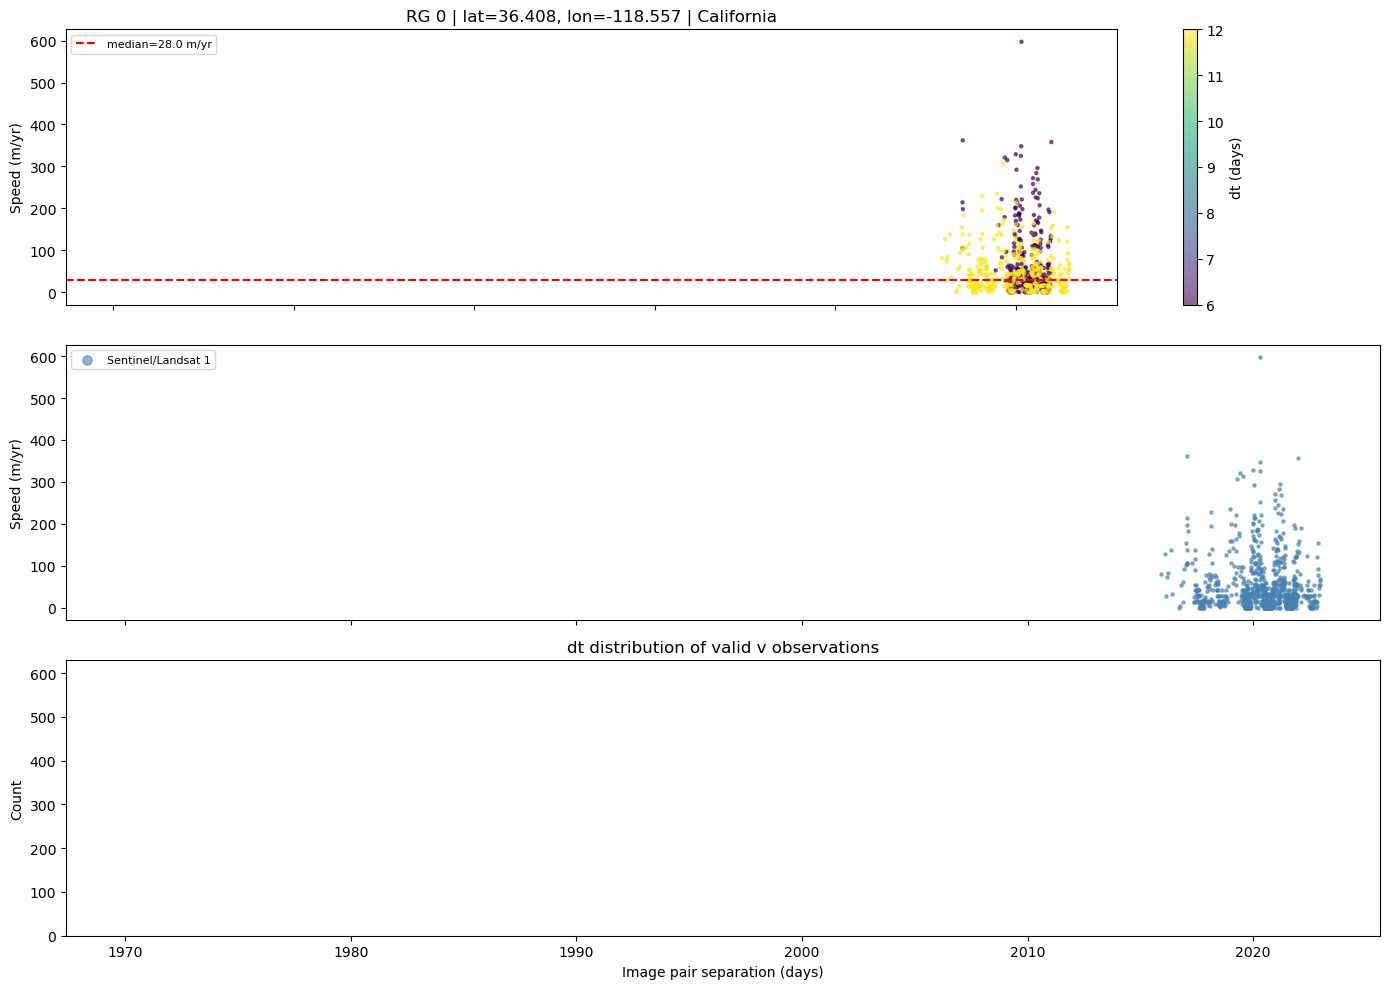


dt stats:
count    979.000000
mean       9.671095
std        2.925473
min        5.999303
25%        6.000558
50%       11.999996
75%       12.000006
max       12.000206
Name: dt_days, dtype: float64

By satellite:
     count       mean        std  min   25%   50%   75%    max
sat                                                           
1    979.0  47.538303  61.010185  0.0  13.0  28.0  56.0  597.0


In [16]:
import matplotlib.pyplot as plt
import numpy as np

test_lon, test_lat = joined_4326.iloc[0][['lon', 'lat']]
test_idx = joined_4326.index[0]

ins3xr, ds_point, point_tilexy = dct.get_timeseries_at_point(
    [test_lon, test_lat], '4326',
    variables=['v', 'vx', 'vy', 'v_error', 'date_dt', 'satellite_img1']
)

df = ds_point.to_dataframe().reset_index().dropna(subset=['v'])
df['dt_days'] = df['date_dt'].dt.total_seconds() / 86400

try:
    df['sat'] = df['satellite_img1'].str[0]
except:
    df['sat'] = df['satellite_img1'].astype(str).str[0]

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

sc = axes[0].scatter(df['mid_date'], df['v'], c=df['dt_days'],
                     cmap='viridis', s=5, alpha=0.6)
plt.colorbar(sc, ax=axes[0], label='dt (days)')
axes[0].set_ylabel('Speed (m/yr)')
axes[0].set_title(f'RG {test_idx} | lat={test_lat:.3f}, lon={test_lon:.3f} | {joined_4326.iloc[0]["STATE"]}')
axes[0].axhline(df['v'].median(), color='red', linewidth=1.5, linestyle='--', 
                label=f'median={df["v"].median():.1f} m/yr')
axes[0].legend(fontsize=8)

sat_colors = {'1': 'steelblue', '2': 'darkorange', '7': 'green', '8': 'purple', '9': 'red'}
for sat, grp in df.groupby('sat'):
    axes[1].scatter(grp['mid_date'], grp['v'],
                    c=sat_colors.get(sat, 'grey'), s=5, alpha=0.6,
                    label=f'Sentinel/Landsat {sat}')
axes[1].set_ylabel('Speed (m/yr)')
axes[1].legend(fontsize=8, markerscale=3)

axes[2].hist(df['dt_days'], bins=50, color='steelblue', edgecolor='white', linewidth=0.3)
axes[2].set_xlabel('Image pair separation (days)')
axes[2].set_ylabel('Count')
axes[2].set_title('dt distribution of valid v observations')

plt.tight_layout()
plt.savefig(f'RG_{test_idx}_velocity_diagnostic.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\ndt stats:\n{df['dt_days'].describe()}")
print(f"\nBy satellite:\n{df.groupby('sat')['v'].describe()}")

### Hmm... takeaway: Feature tracking (ITS_LIVE): Finds the same surface features in two SAR images taken 6-12 days apart and measures how far they've moved. Resolution is limited by the pixel size (~120m), so the minimum detectable velocity is >5 m/yr. That's why we're seeing noise at rock glacier speeds.

## Trying Sentinel-1 InSAR approach 
## Andreas Kääb & Julie Røste 2024 "Rock glaciers across the United States predominantly accelerate coincident with rise in air temperatures"
### Start by pulling their data for CA glaciers that overlap with our ASO flights 

In [25]:
import requests
import pandas as pd
import zipfile
import io
from pathlib import Path

Path('kaab_validation').mkdir(exist_ok=True)

zip_url = "https://zenodo.org/records/13254373/files/conus_rockglaciers_displacements.zip"
print("Downloading Zenodo zip...")
r = requests.get(zip_url)
z = zipfile.ZipFile(io.BytesIO(r.content))

ca_prefixes = ('pine_', 'birch_', 'cardinal_')
ca_files = [f for f in z.namelist() if any(f.startswith(p) for p in ca_prefixes)]
print(f"CA files found: {len(ca_files)}")
z.extractall('kaab_validation', members=ca_files)

records = []
for fname in sorted(ca_files):
    parts = fname.replace('.txt','').replace('.csv','').split('_')
    site = parts[0]
    year1, year2 = int(parts[1]), int(parts[2])
    dt_years = year2 - year1

    df = pd.read_csv(f'kaab_validation/{fname}', skipinitialspace=True)
    df = df.dropna()
    df['v_myr'] = df['length'] / dt_years

    records.append({
        'site':         site,
        'year1':        year1,
        'year2':        year2,
        'dt_years':     dt_years,
        'n_pts':        len(df),
        'v_median_myr': df['v_myr'].median(),
        'v_mean_myr':   df['v_myr'].mean(),
        'v_std_myr':    df['v_myr'].std(),
        'file':         fname,
    })
    print(f"{fname}: n={len(df)}, v_median={df['v_myr'].median():.3f} m/yr")

df_kaab = pd.DataFrame(records)
df_kaab['lat'] = df_kaab['site'].map({'pine': 37.078, 'birch': 37.065, 'cardinal': 37.011})
df_kaab['lon'] = df_kaab['site'].map({'pine': -118.450, 'birch': -118.431, 'cardinal': -118.414})

df_kaab.to_csv('kaab_validation/kaab_CA_summary.csv', index=False)
print(f"\nSummary:")
print(df_kaab[['site','year1','year2','v_median_myr','n_pts']].to_string(index=False))

CA files found: 11
birch_1947_1987_40_120_helm.txt: n=94, v_median=0.439 m/yr
birch_1987_2005_40_100_helm.txt: n=85, v_median=0.239 m/yr
birch_2005_2022_50_100_helm.txt: n=133, v_median=0.336 m/yr
cardinal_1947_1987_40_150_helm.txt: n=196, v_median=0.549 m/yr
cardinal_1987_2005_40_150_helm.txt: n=279, v_median=0.594 m/yr
cardinal_2005_2016_40_100_helm.txt: n=388, v_median=0.642 m/yr
cardinal_2016_2022_40_100_helm.txt: n=1888, v_median=0.421 m/yr
pine_1947_1987_40_100_helm.txt: n=106, v_median=0.346 m/yr
pine_1987_2005_40_100_helm.txt: n=186, v_median=0.372 m/yr
pine_2005_2016_40_100_helm.txt: n=196, v_median=0.364 m/yr
pine_2016_2022_40_100_helm.txt: n=237, v_median=0.422 m/yr

Summary:
    site  year1  year2  v_median_myr  n_pts
   birch   1947   1987      0.439221     94
   birch   1987   2005      0.239272     85
   birch   2005   2022      0.336059    133
cardinal   1947   1987      0.548911    196
cardinal   1987   2005      0.593967    279
cardinal   2005   2016      0.641964    

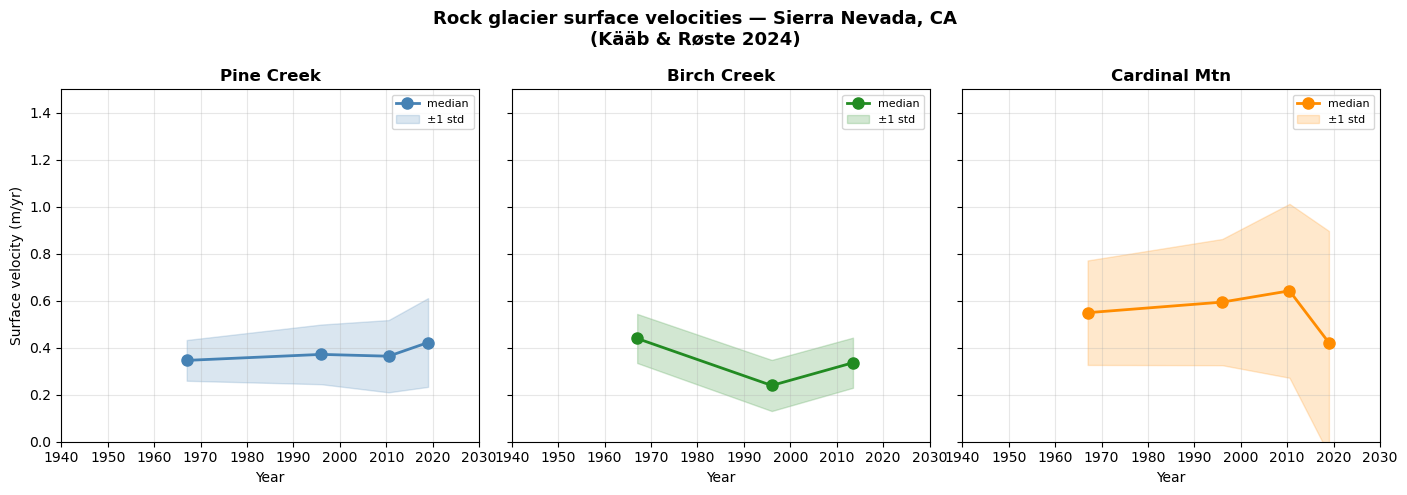

In [26]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

sites = ['pine', 'birch', 'cardinal']
titles = ['Pine Creek', 'Birch Creek', 'Cardinal Mtn']
colors = ['steelblue', 'forestgreen', 'darkorange']

for ax, site, title, color in zip(axes, sites, titles, colors):
    df_site = df_kaab[df_kaab['site'] == site].copy()
    df_site['mid_year'] = (df_site['year1'] + df_site['year2']) / 2

    ax.plot(df_site['mid_year'], df_site['v_median_myr'],
            'o-', color=color, linewidth=2, markersize=8, label='median')
    ax.fill_between(df_site['mid_year'],
                    df_site['v_median_myr'] - df_site['v_std_myr'],
                    df_site['v_median_myr'] + df_site['v_std_myr'],
                    alpha=0.2, color=color, label='±1 std')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_xlim(1940, 2030)
    ax.set_ylim(0, 1.5)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)

axes[0].set_ylabel('Surface velocity (m/yr)')
fig.suptitle('Rock glacier surface velocities — Sierra Nevada, CA\n(Kääb & Røste 2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kaab_CA_velocity_timeseries.png', dpi=200, bbox_inches='tight')
plt.show()